In [45]:
import math
from cvxopt import solvers, matrix, spmatrix, mul
from scipy import sparse
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import math
from cvxopt import solvers, matrix, spmatrix, mul
from scipy import sparse
from numpy import linalg as LA
from numba import njit, prange, cuda
%config InlineBackend.figure_format = 'retina'


def fit_J(w, expn, etal):
    res = np.zeros_like(w, dtype=complex)
    for i in range(len(etal)):
        res += etal[i] / (expn[i] - 1.j * w)
    return res

def fit_t(t, expn, etal):
    res = np.zeros_like(t, dtype=complex)
    for i in range(len(etal)):
        res += etal[i] * np.exp(-expn[i] * t)
    return res


def numpy_to_cvxopt_matrix(A):
    if A is None:
        return A
    if sparse.issparse(A):
        if isinstance(A, sparse.spmatrix):
            return scipy_sparse_to_spmatrix(A)
        else:
            return A
    else:
        if isinstance(A, np.ndarray):
            if A.ndim == 1:
                return matrix(A, (A.shape[0], 1), 'd')
            else:
                return matrix(A, A.shape, 'd')
        else:
            return A

(-100.0, 100.0)

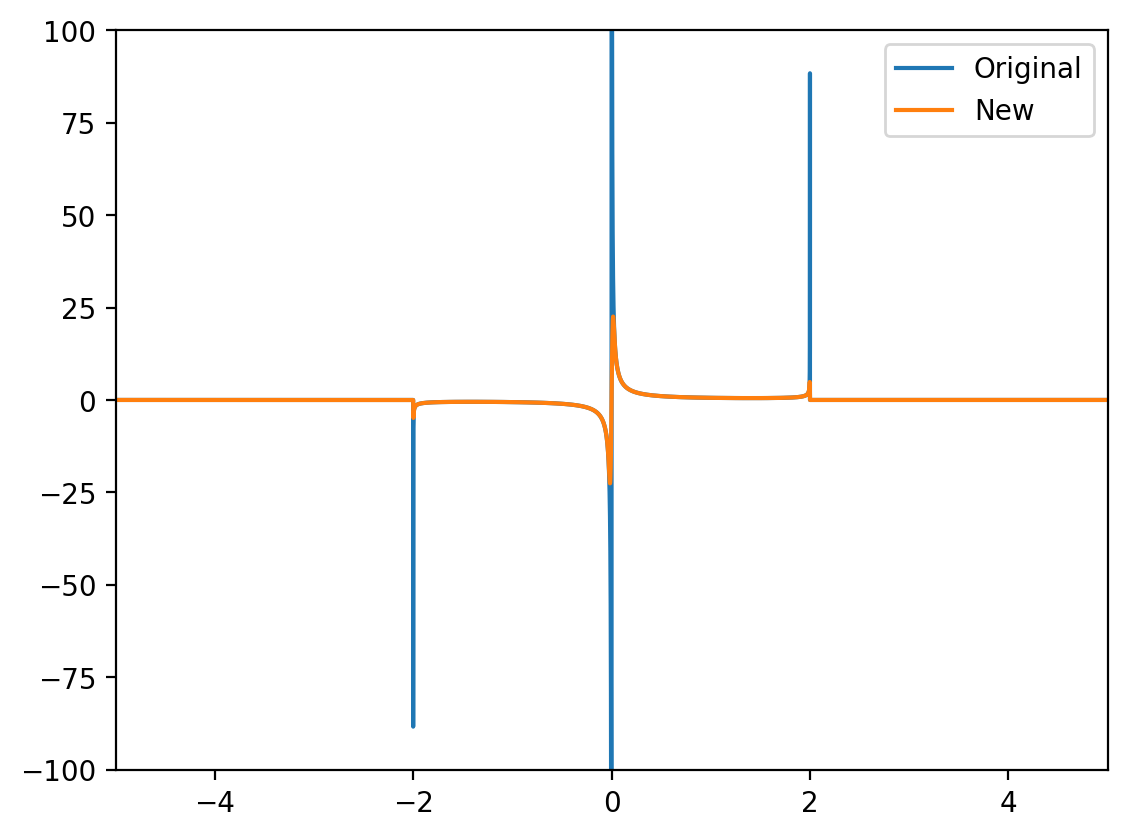

In [ ]:
gams1 = 2
lams1 = 1

beta = 100

m = 1
kappa = 1
u = 1
v = 1
Omg = np.sqrt(kappa / m)

sig1 = 0.001*Omg
sig0 = 0.01*Omg

def gen_jw_2(w):
    if np.abs(w) < 2 * Omg:
        return np.cos( 2 * np.arcsin(w * np.sqrt(m / kappa) / 2) * (u - v))  / (w * m * np.sqrt(4 * Omg**2 - w**2))
    else:
        return 0

def gen_jw(w):
    if (np.abs(w) >= 2 * Omg) or (w == 0.0):
        return 0.0

    def _jw2_pos(wp):
        jw = 1/ (wp * m * np.sqrt(4 * Omg**2 - wp**2))

        factor1 = 1 - np.exp(-(wp - 2*Omg)**2 / (2 * sig1**2))
        factor2 = 1 - np.exp(-wp**2 / (2 * sig0**2))

        return jw * factor1 * factor2
    return _jw2_pos(w) if (w > 0) else -_jw2_pos(-w)

len_ = 1000000
spe_wid = 10
w = np.linspace(-spe_wid, spe_wid, len_)

sigma = 1

jw = np.array([gen_jw(wi) for wi in w])
jw2 = np.array([gen_jw_2(wi) for wi in w])
plt.plot(w, jw2, label="Original")
plt.plot(w, jw, label="New")
plt.legend()
plt.xlim(-5, 5)
plt.ylim(-100, 100)


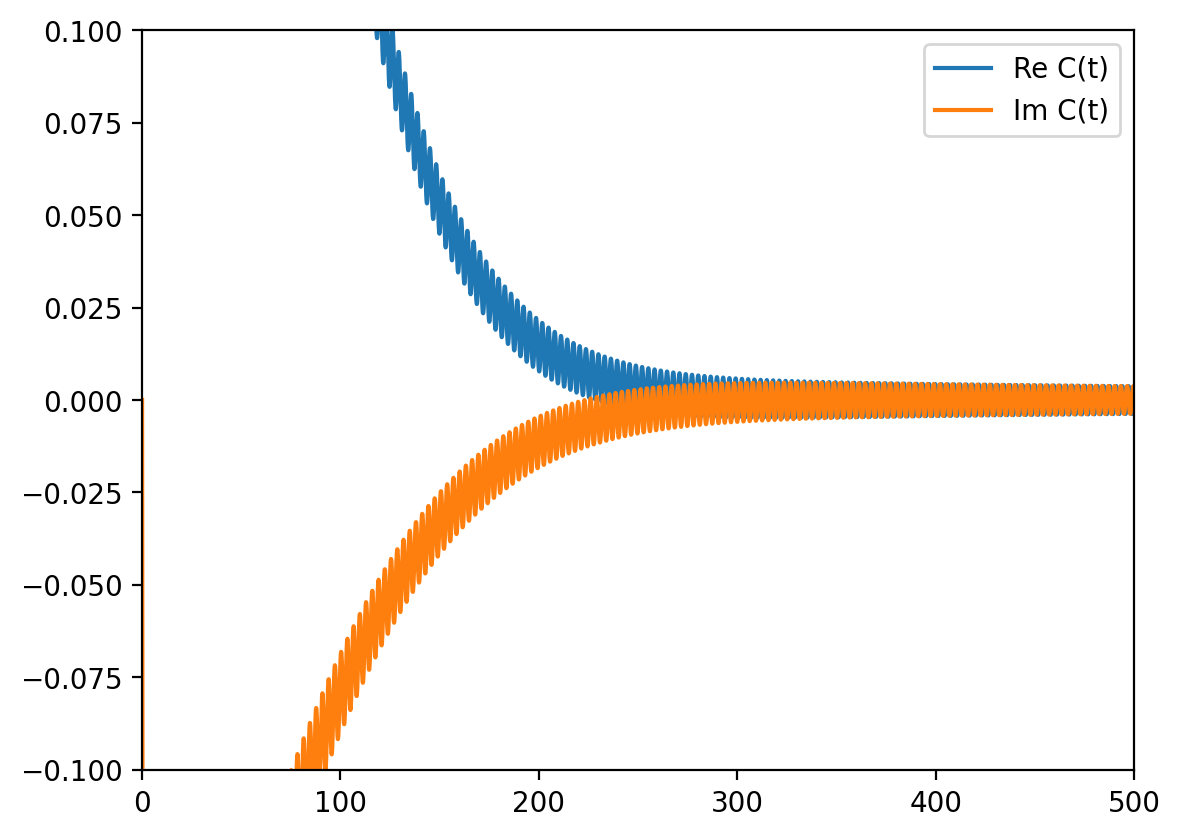

In [47]:
try:
    from scipy.integrate import simpson
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def bose_denom(w, beta):
    return -np.expm1(-beta * w)  # = 1 - exp(-beta*w)


def Ct_simpson_from_genjw(t, beta, Omg, gen_jw, N, eps0=1e-6, eps_edge=1e-10):
    a = 2.0 * Omg
    wpos = np.linspace(eps0, a - eps_edge, N)

    Jpos = np.array([gen_jw(w) for w in wpos])
    Jneg = np.array([gen_jw(-w) for w in wpos])

    dpos = bose_denom(wpos, beta)
    dneg = bose_denom(-wpos, beta)

    fpos = (Jpos / dpos) * np.exp(-1j * wpos * t)
    fneg = (Jneg / dneg) * np.exp(-1j * (-wpos) * t)
    integrand = fpos + fneg

    if _HAS_SCIPY:
        integral = simpson(integrand, wpos)
    else:
        integral = np.trapz(integrand, wpos)

    return integral / np.pi



if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    n = 2500
    scale = 500

    ts = np.linspace(0, scale, 2 * n + 1)
    Ct = np.array([Ct_simpson_from_genjw(t, beta, Omg, gen_jw, N=1000) for t in ts])

    plt.plot(ts, Ct.real, label="Re C(t)")
    plt.plot(ts, Ct.imag, label="Im C(t)")
    plt.legend()
    plt.xlim(0, 500)
    plt.ylim(-0.1, 0.1)
    plt.show()


In [ ]:
res_t = Ct.copy()
print(res_t[-10:])
n_sample = n 
print(len(ts), n_sample)
h = res_t
H_r = np.zeros((n_sample, n_sample))
H_i = np.zeros((n_sample, n_sample))
for i in range(n_sample):
    H_r[i, :] = np.real(h[i:n_sample + i])
    H_i[i, :] = np.imag(h[i:n_sample + i])    

sing_vs_r, Q_r = LA.eigh(H_r)
sing_vs_i, Q_i = LA.eigh(H_i)
phase_mat_r = np.diag(
    [np.exp(-1j * np.angle(sing_v_r) / 2.0) for sing_v_r in sing_vs_r])
vs_r = np.array([np.abs(sing_v_r) for sing_v_r in sing_vs_r])
Qp_r = np.dot(Q_r, phase_mat_r)
sort_array = np.argsort(vs_r)[::-1]
vs_r = vs_r[sort_array]
Qp_r = Qp_r[:, sort_array]

phase_mat_i = np.diag(
    [np.exp(-1j * np.angle(sing_v_i) / 2.0) for sing_v_i in sing_vs_i])
vs_i = np.array([np.abs(sing_v_i) for sing_v_i in sing_vs_i])
Qp_i = np.dot(Q_i, phase_mat_i)
sort_array = np.argsort(vs_i)[::-1]
vs_i = vs_i[sort_array]
Qp_i = Qp_i[:, sort_array]

for n_gamma_r, n_gamma_i in ([[6, 6]]):
    print("len of gamma", n_gamma_r)
    for i in [n_gamma_r]:
        print(i)
        gamma_r = np.roots(Qp_r[:,i][::-1])
    gamma_new_r = gamma_r[np.argsort(np.abs(gamma_r))[:n_gamma_r]]
    t_new_r = 2*n*np.log(gamma_new_r)
    
    print("len of gamma", n_gamma_i)
    for i in [n_gamma_i]:
        print(i)
        gamma_i = np.roots(Qp_i[:,i][::-1])
    gamma_new_i = gamma_i[np.argsort(np.abs(gamma_i))[:n_gamma_i]]
    t_new_i = 2*n*np.log(gamma_new_i)
    
    gamma_new = np.append(gamma_new_r, gamma_new_i)
    t_new = np.append(t_new_r, t_new_i)
    n_gamma = n_gamma_r + n_gamma_i
    
    n_col = n_sample*2+1
    n_row = n_gamma
    gamma_m = np.zeros((2 * n_col, 2 * n_row), dtype=float)
    for i in range(n_row):
        for j in range(n_col):
            gamma_m[j, i] = np.real(gamma_new[i]**j)
            gamma_m[n_col + j, n_row + i] = np.real(gamma_new[i]**j)
            gamma_m[j, n_row + i] = -np.imag(gamma_new[i]**j)
            gamma_m[n_col + j, i] = np.imag(gamma_new[i]**j)
    h_m = np.append(np.real(h), np.imag(h))

    # freq_d = np.linspace(-1000, 1000, 2 * n_col)
    freq_d = np.append(np.append(np.linspace(-10000, 10, n_col//2), np.linspace(-10, 10, n_col + 1)), np.linspace(10, 10000, n_col//2))

    freq_m = np.zeros((2 * n_col, 2 * n_row), dtype=float)
    expn = -t_new / scale
    for i in range(n_row):
        for j in range(2 * n_col):
            freq_m[j, i] = np.real(expn[i]) / (np.real(expn[i])**2 + (np.imag(expn[i]) - freq_d[j])**2)
            freq_m[j, n_row + i] = (np.imag(expn[i]) - freq_d[j]) / (np.real(expn[i])**2 + (np.imag(expn[i]) - freq_d[j])**2)

    C = numpy_to_cvxopt_matrix(gamma_m)
    d = numpy_to_cvxopt_matrix(h_m)
    A = numpy_to_cvxopt_matrix(-freq_m)
    b = numpy_to_cvxopt_matrix(np.zeros(2 * n_col))
    Q = C.T * C
    q = - d.T * C

    opts = {'show_progress': True, 'abstol': 1e-24, 'reltol': 1e-24, 'feastol': 1e-24}
    for k, v in opts.items():
        solvers.options[k] = v
    sol = solvers.qp(Q, q.T, A, b, None, None, None, None)
    
    omega_new_temp = np.array(sol['x']).reshape(2, n_gamma)
    omega_new = omega_new_temp[0,:] + 1.j*omega_new_temp[1,:]
    print(omega_new)

    
    etal = omega_new.copy()
    expn = -t_new / scale


[-0.00330723+0.00183952j -0.00287645+0.0024528j  -0.00233257+0.00296829j
 -0.00169726+0.00336549j -0.00099583+0.00362864j -0.00025622+0.00374728j
  0.00049214+0.00371673j  0.00121944+0.00353825j  0.00189675+0.00321897j
  0.00249712+0.00277164j]
5001 2500
len of gamma 6
6
len of gamma 6
6
     pcost       dcost       gap    pres   dres
 0: -3.4285e+00 -2.9364e+01  2e+04  1e+02  9e+00
 1: -1.1225e+01 -1.5492e+03  9e+03  5e+01  4e+00
 2: -3.1128e+01 -1.8839e+03  7e+03  3e+01  3e+00
 3: -4.1546e+01 -1.7280e+03  5e+03  2e+01  2e+00
 4: -1.1829e+01 -1.0747e+03  2e+03  7e+00  6e-01
 5: -4.0728e+01 -5.2650e+02  1e+03  3e+00  2e-01
 6: -8.4109e+01 -2.4214e+02  3e+02  6e-01  5e-02
 7: -1.2234e+02 -1.5843e+02  5e+01  7e-02  6e-03
 8: -1.3339e+02 -1.4152e+02  1e+01  1e-02  8e-04
 9: -1.3592e+02 -1.3774e+02  2e+00  1e-03  1e-04
10: -1.3623e+02 -1.3718e+02  1e+00  6e-04  5e-05
11: -1.3635e+02 -1.3691e+02  7e-01  3e-04  3e-05
12: -1.3642e+02 -1.3671e+02  4e-01  2e-04  1e-05
13: -1.3645e+02 -1.3659e+0

/var/folders/81/34y_2x2j7_ng1c4vpqpqbgnr0000gn/T/ipykernel_79126/3891736956.py:10: RuntimeWarning: overflow encountered in exp
  jw1 = jw / (1 - np.exp(-beta * w))


(-1.0, 35.0)

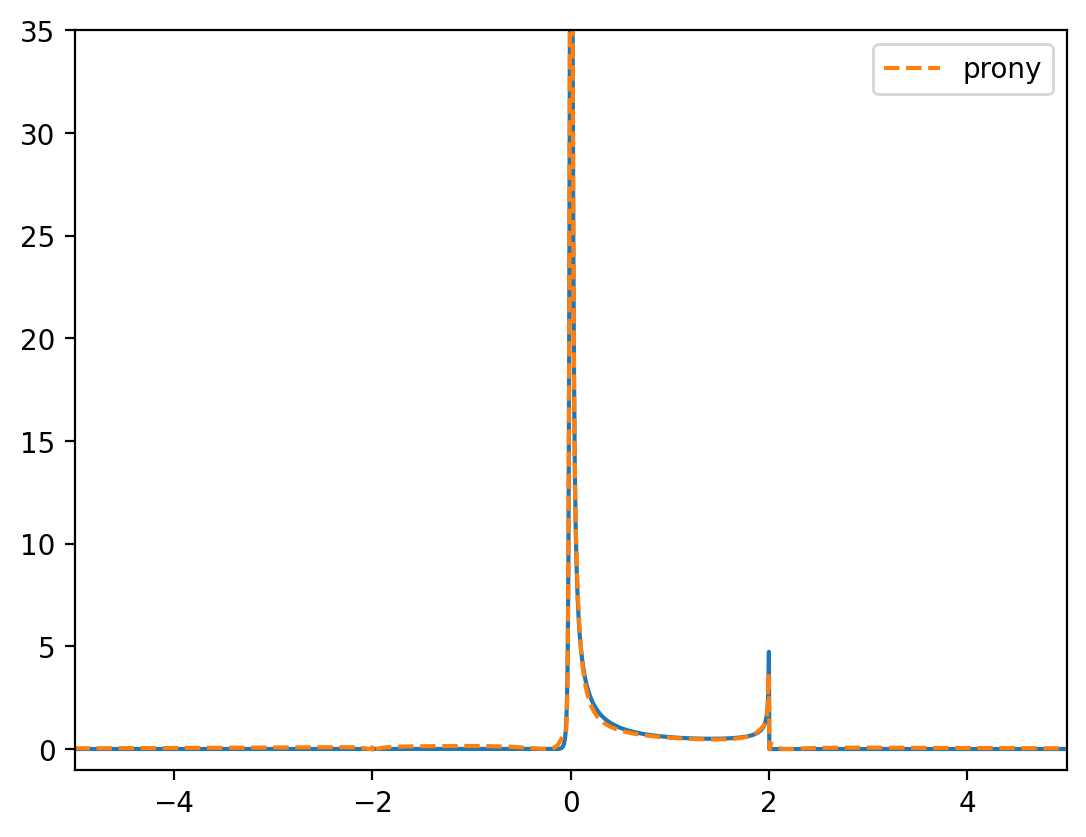

In [52]:
etal1 = etal
expn1 = expn

len_ = 10000
spe_wid = 20
w = np.linspace(-spe_wid, spe_wid, len_)
res = fit_J(w, expn1, etal1)

jw = np.array([gen_jw(wi) for wi in w])
jw1 = jw / (1 - np.exp(-beta * w))
# plt.plot(w, jw)
plt.plot(w, jw1)
plt.plot(w, res, '--',label="prony")
plt.legend()
plt.xlim(-5, 5)
plt.ylim(-1, 35)

In [ ]:
etal1
np.savetxt('etal1',etal1)

array([ 0.63095621+0.14204333j, -0.38251319+0.06698304j,
       -0.33383817-0.20366411j,  2.19568023+0.37433049j,
        0.00383145+0.00103491j,  0.00305702+0.00279643j,
        0.04877834+0.05416353j, -0.01282899+0.00067753j,
       -0.00722636-0.36445361j, -0.47588174-0.08375183j,
       -0.0025133 -0.00075509j,  0.00684854+0.01049595j])

In [51]:
expn1
np.savetxt('expn1',expn1)

In [31]:
print(sum(e * x for e, x in zip(etal1, expn1)))

(0.5204529908995084+0.06548342302494602j)
